In [15]:
import torch
import time
import numpy as np
from src.utils import make_run_dir, set_seed
from src.dataset import get_downloaders, get_transforms
from src.engine import train_and_evaluate_model, measure_inference_speed
from src.visualization import plot_loss_history, plot_weight_tradeoff, plot_model_comparison_pareto, show_gradcam_grid, plot_model_comparison_bar, plot_confusion_matrix

In [16]:
# 1. 시드 고정 및 디바이스 설정
set_seed(42)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"현재 사용 중인 디바이스: {device}")

# 2. 이번 실험의 결과물이 저장될 고유 방(폴더) 생성
run_dirs = make_run_dir('./outputs')

현재 사용 중인 디바이스: cuda:0
새로운 실험 결과 폴더가 생성되었습니다: ./outputs\run_20260314_000419


In [17]:
data_dir = './data/new_screw_data' 

# GPU 33GB+ 여유 있으면 batch_size 128~256 권장 (학습 속도 ↑)
dataloaders, image_datasets = get_downloaders(data_dir, batch_size=128)
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val', 'test']}
class_names = image_datasets['train'].classes # ['bad', 'good']

print(f"데이터 클래스: {class_names}")
print(f"데이터 개수: Train {dataset_sizes['train']}장 | Val {dataset_sizes['val']}장 | Test {dataset_sizes['test']}장")

데이터 클래스: ['bad', 'good']
데이터 개수: Train 800장 | Val 99장 | Test 100장


In [18]:
bad_weights = np.arange(1.0, 10.5, 0.5).tolist()
best_models_dict = {}
best_f2_scores = []
fps_list = []


[ 시작 ] 모델 학습 및 평가: RESNET18

현재 탐색 중인 bad weight : 1.0
Epoch 01/40 | Train Loss: 0.6410 | Val Loss: 0.6275
Epoch 10/40 | Train Loss: 0.2595 | Val Loss: 0.3725
Epoch 20/40 | Train Loss: 0.1228 | Val Loss: 0.3714
Epoch 30/40 | Train Loss: 0.0797 | Val Loss: 0.3918
Epoch 40/40 | Train Loss: 0.0608 | Val Loss: 0.3391
[Validation] 가중치 1.0 | F2: 0.8471 | Recall: 0.8200

현재 탐색 중인 bad weight : 1.5
Epoch 01/40 | Train Loss: 0.6204 | Val Loss: 0.6063
Epoch 10/40 | Train Loss: 0.2362 | Val Loss: 0.3634
Epoch 20/40 | Train Loss: 0.1316 | Val Loss: 0.3476
Epoch 30/40 | Train Loss: 0.0744 | Val Loss: 0.3460
Epoch 40/40 | Train Loss: 0.0419 | Val Loss: 0.2813
[Validation] 가중치 1.5 | F2: 0.8607 | Recall: 0.8400

현재 탐색 중인 bad weight : 2.0
Epoch 01/40 | Train Loss: 0.6387 | Val Loss: 0.5552
Epoch 10/40 | Train Loss: 0.2229 | Val Loss: 0.2831
Epoch 20/40 | Train Loss: 0.1083 | Val Loss: 0.2270
Epoch 30/40 | Train Loss: 0.0899 | Val Loss: 0.1594
Epoch 40/40 | Train Loss: 0.0620 | Val Loss: 0.1799
[Validat

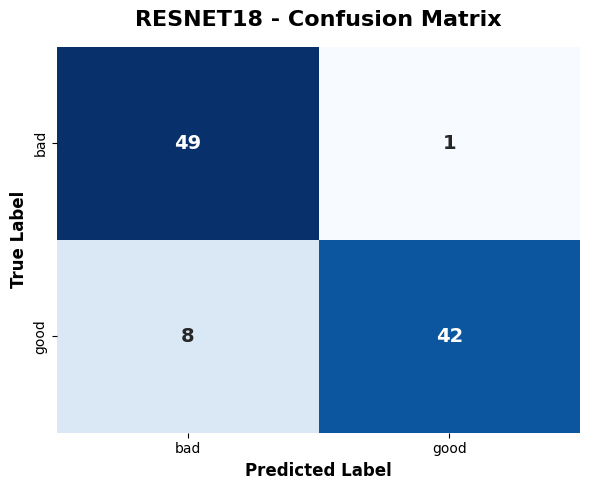

<Figure size 640x480 with 0 Axes>

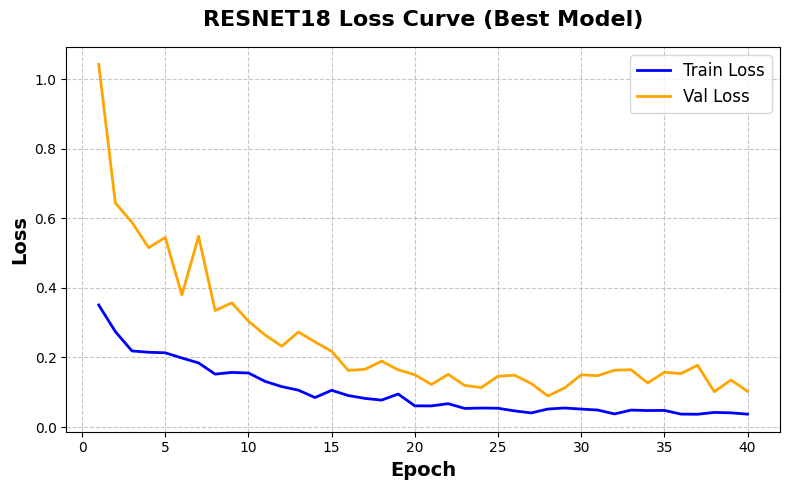

<Figure size 640x480 with 0 Axes>

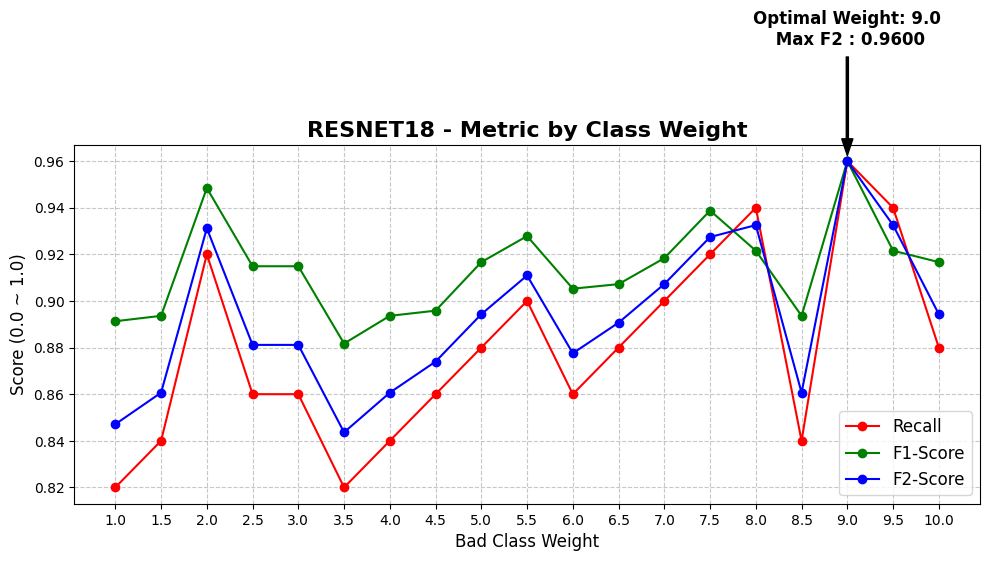

<Figure size 640x480 with 0 Axes>

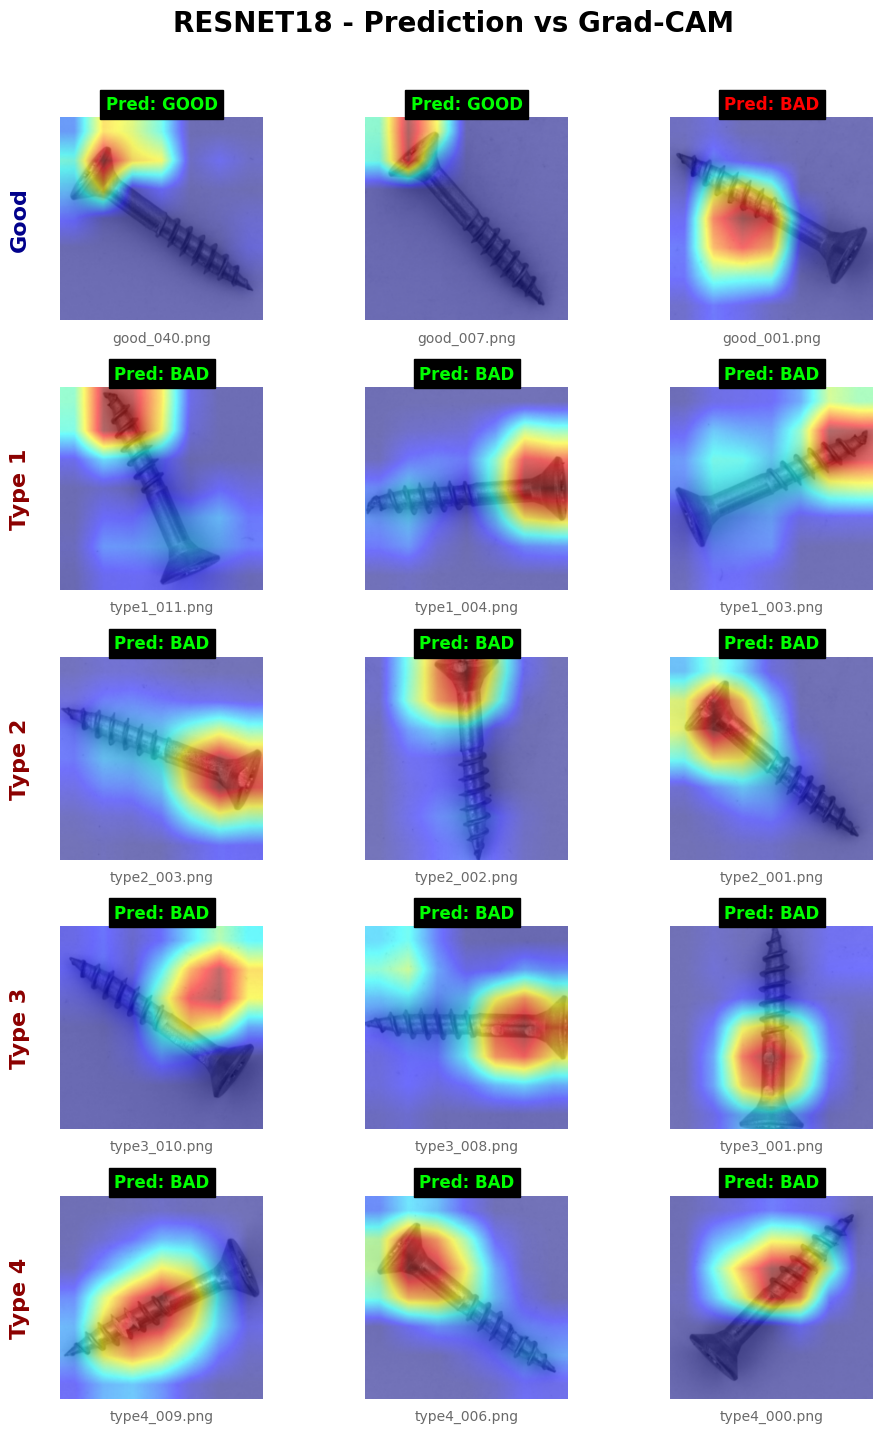

<Figure size 640x480 with 0 Axes>

In [19]:
model_name = 'resnet18'

best_model, val_recalls, val_f1s, val_f2_scores, test_y_true, test_y_pred, train_loss, val_loss = train_and_evaluate_model(
    model_name=model_name,
    dataloaders=dataloaders,
    dataset_sizes=dataset_sizes,
    class_names=class_names,
    device=device,
    run_dirs=run_dirs,
    num_epochs=40 
    )

best_f2 = max(val_f2_scores)
best_f2_scores.append(best_f2)
best_models_dict[model_name] = best_model

plot_confusion_matrix(test_y_true, test_y_pred, class_names, run_dirs['figures'], model_name=model_name)
plot_loss_history(train_loss, val_loss, run_dirs['figures'], model_name=model_name)
plot_weight_tradeoff(bad_weights, val_recalls, val_f1s, val_f2_scores, run_dirs['figures'], model_name=model_name)

test_transform = get_transforms()['test']
base_test_dir = f'{data_dir}/test'
show_gradcam_grid(best_model, test_transform, base_test_dir, device, run_dirs['figures'], model_name=model_name)



[ 시작 ] 모델 학습 및 평가: MOBILENET_V2

현재 탐색 중인 bad weight : 1.0
Epoch 01/40 | Train Loss: 0.6872 | Val Loss: 0.6956
Epoch 10/40 | Train Loss: 0.3151 | Val Loss: 0.4838
Epoch 20/40 | Train Loss: 0.2460 | Val Loss: 0.3835
Epoch 30/40 | Train Loss: 0.1773 | Val Loss: 0.3621
Epoch 40/40 | Train Loss: 0.1603 | Val Loss: 0.3631
[Validation] 가중치 1.0 | F2: 0.7676 | Recall: 0.7400

현재 탐색 중인 bad weight : 1.5
Epoch 01/40 | Train Loss: 0.6754 | Val Loss: 0.6799
Epoch 10/40 | Train Loss: 0.3210 | Val Loss: 0.4671
Epoch 20/40 | Train Loss: 0.2140 | Val Loss: 0.3695
Epoch 30/40 | Train Loss: 0.1898 | Val Loss: 0.2963
Epoch 40/40 | Train Loss: 0.1956 | Val Loss: 0.3295
[Validation] 가중치 1.5 | F2: 0.8197 | Recall: 0.8000

현재 탐색 중인 bad weight : 2.0
Epoch 01/40 | Train Loss: 0.6429 | Val Loss: 0.6635
Epoch 10/40 | Train Loss: 0.2913 | Val Loss: 0.3507
Epoch 20/40 | Train Loss: 0.1970 | Val Loss: 0.3088
Epoch 30/40 | Train Loss: 0.1967 | Val Loss: 0.3015
Epoch 40/40 | Train Loss: 0.1651 | Val Loss: 0.2959
[Val

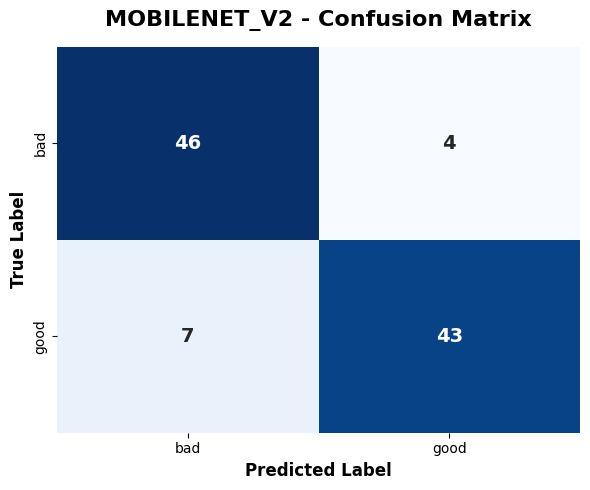

<Figure size 640x480 with 0 Axes>

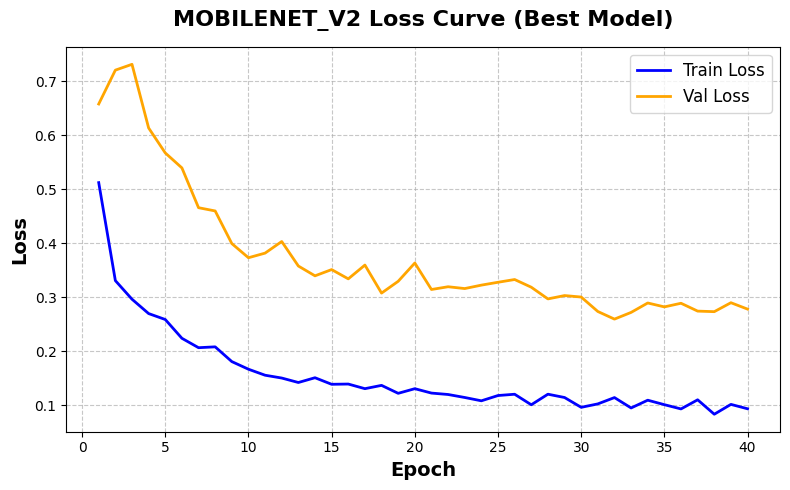

<Figure size 640x480 with 0 Axes>

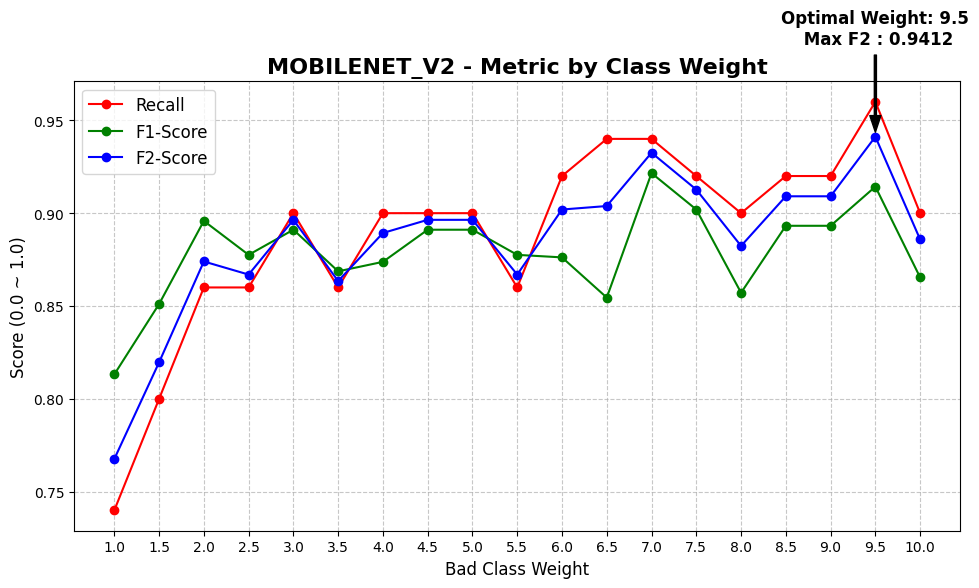

<Figure size 640x480 with 0 Axes>

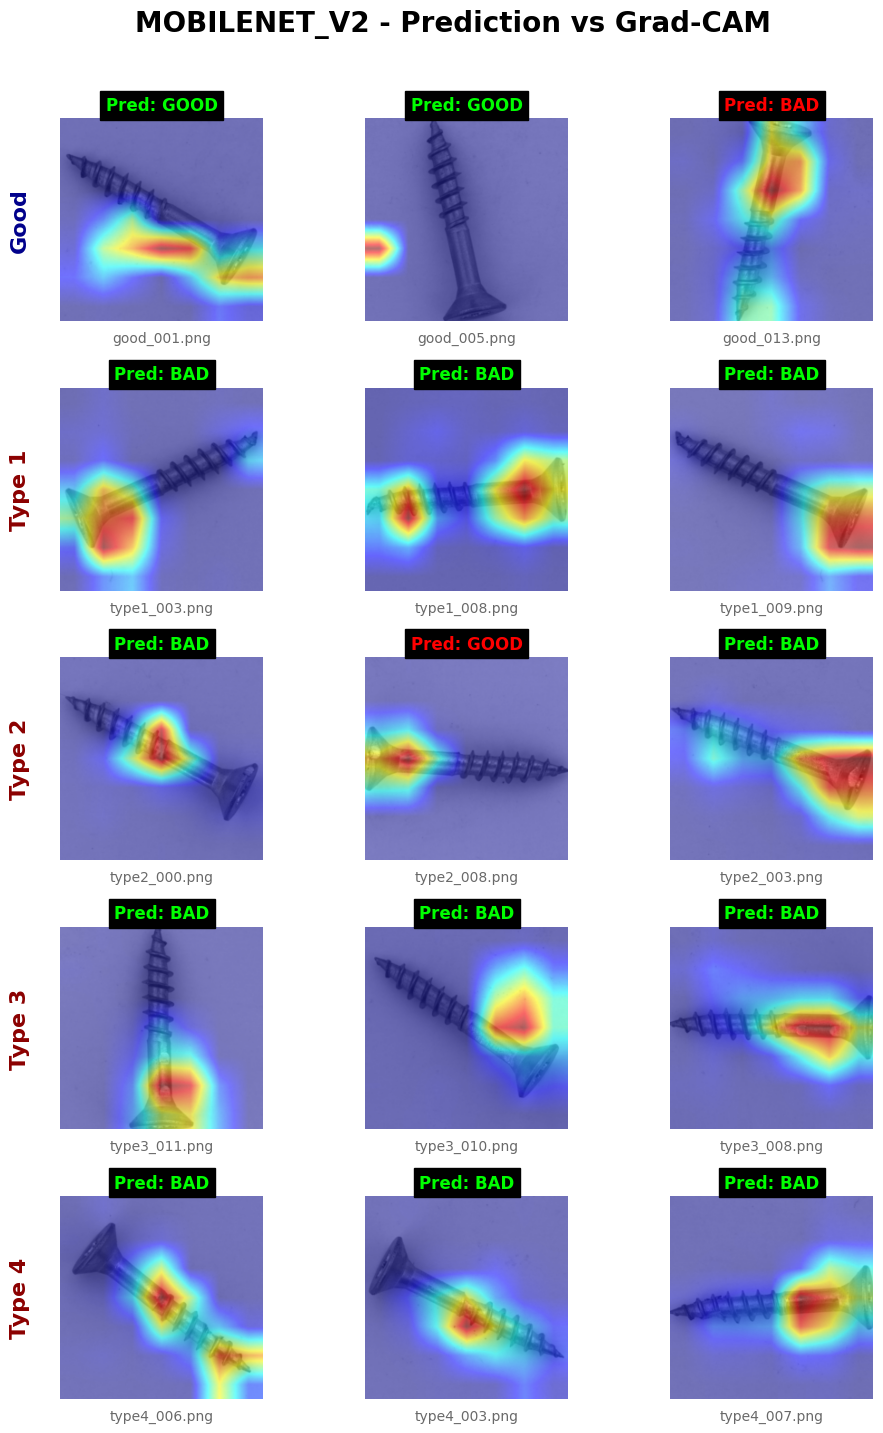

<Figure size 640x480 with 0 Axes>

In [20]:
model_name = 'mobilenet_v2'

best_model, val_recalls, val_f1s, val_f2_scores, test_y_true, test_y_pred, train_loss, val_loss = train_and_evaluate_model(
    model_name=model_name,
    dataloaders=dataloaders,
    dataset_sizes=dataset_sizes,
    class_names=class_names,
    device=device,
    run_dirs=run_dirs,
    num_epochs=40 
    )

best_f2 = max(val_f2_scores)
best_f2_scores.append(best_f2)
best_models_dict[model_name] = best_model

plot_confusion_matrix(test_y_true, test_y_pred, class_names, run_dirs['figures'], model_name=model_name)
plot_loss_history(train_loss, val_loss, run_dirs['figures'], model_name=model_name)
plot_weight_tradeoff(bad_weights, val_recalls, val_f1s, val_f2_scores, run_dirs['figures'], model_name=model_name)

test_transform = get_transforms()['test']
base_test_dir = f'{data_dir}/test'
show_gradcam_grid(best_model, test_transform, base_test_dir, device, run_dirs['figures'], model_name=model_name)


[ 시작 ] 모델 학습 및 평가: VGG16

현재 탐색 중인 bad weight : 1.0
Epoch 01/40 | Train Loss: 0.7261 | Val Loss: 0.7009
Epoch 10/40 | Train Loss: 0.3898 | Val Loss: 0.3465
Epoch 20/40 | Train Loss: 0.1650 | Val Loss: 0.1905
Epoch 30/40 | Train Loss: 0.0451 | Val Loss: 0.3157
Epoch 40/40 | Train Loss: 0.0212 | Val Loss: 0.2330
[Validation] 가중치 1.0 | F2: 0.8848 | Recall: 0.8600

현재 탐색 중인 bad weight : 1.5
Epoch 01/40 | Train Loss: 0.6991 | Val Loss: 0.6806
Epoch 10/40 | Train Loss: 0.4108 | Val Loss: 0.2920
Epoch 20/40 | Train Loss: 0.1357 | Val Loss: 0.3962
Epoch 30/40 | Train Loss: 0.0697 | Val Loss: 0.1596
Epoch 40/40 | Train Loss: 0.0268 | Val Loss: 0.0644
[Validation] 가중치 1.5 | F2: 0.9600 | Recall: 0.9600

현재 탐색 중인 bad weight : 2.0
Epoch 01/40 | Train Loss: 0.6581 | Val Loss: 0.6572
Epoch 10/40 | Train Loss: 0.2873 | Val Loss: 0.4616
Epoch 20/40 | Train Loss: 0.1071 | Val Loss: 0.4509
Epoch 30/40 | Train Loss: 0.0358 | Val Loss: 0.2909
Epoch 40/40 | Train Loss: 0.0093 | Val Loss: 0.5229
[Validation

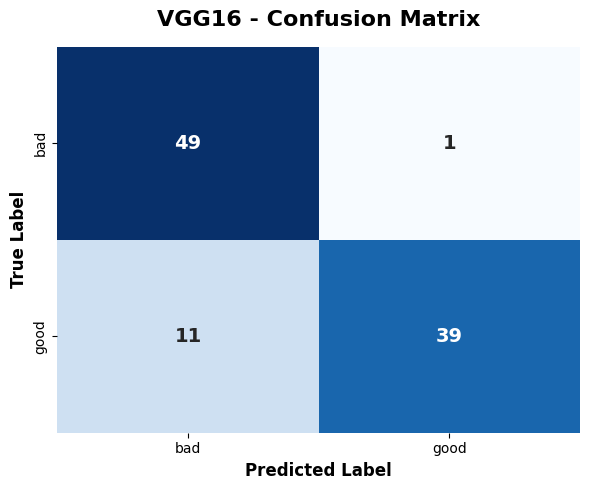

<Figure size 640x480 with 0 Axes>

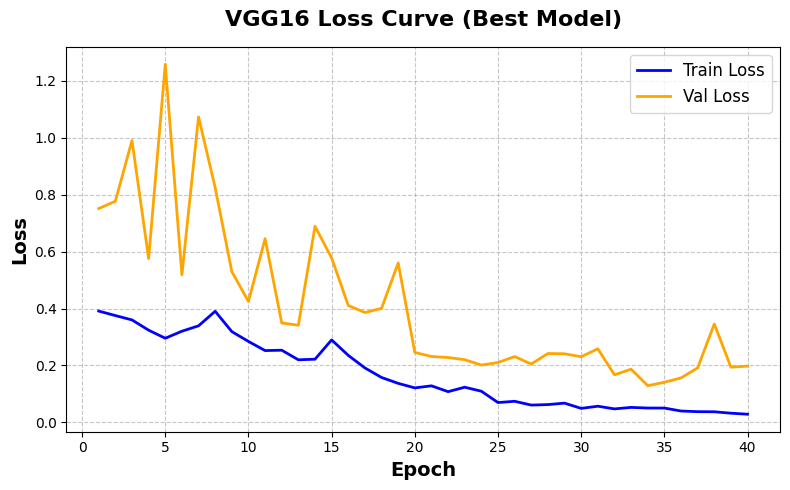

<Figure size 640x480 with 0 Axes>

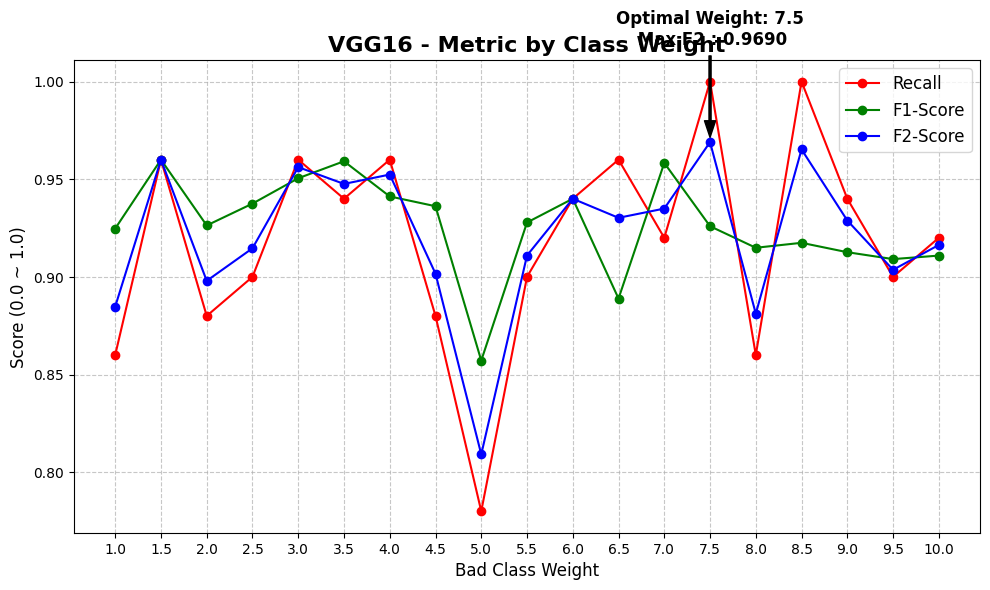

<Figure size 640x480 with 0 Axes>

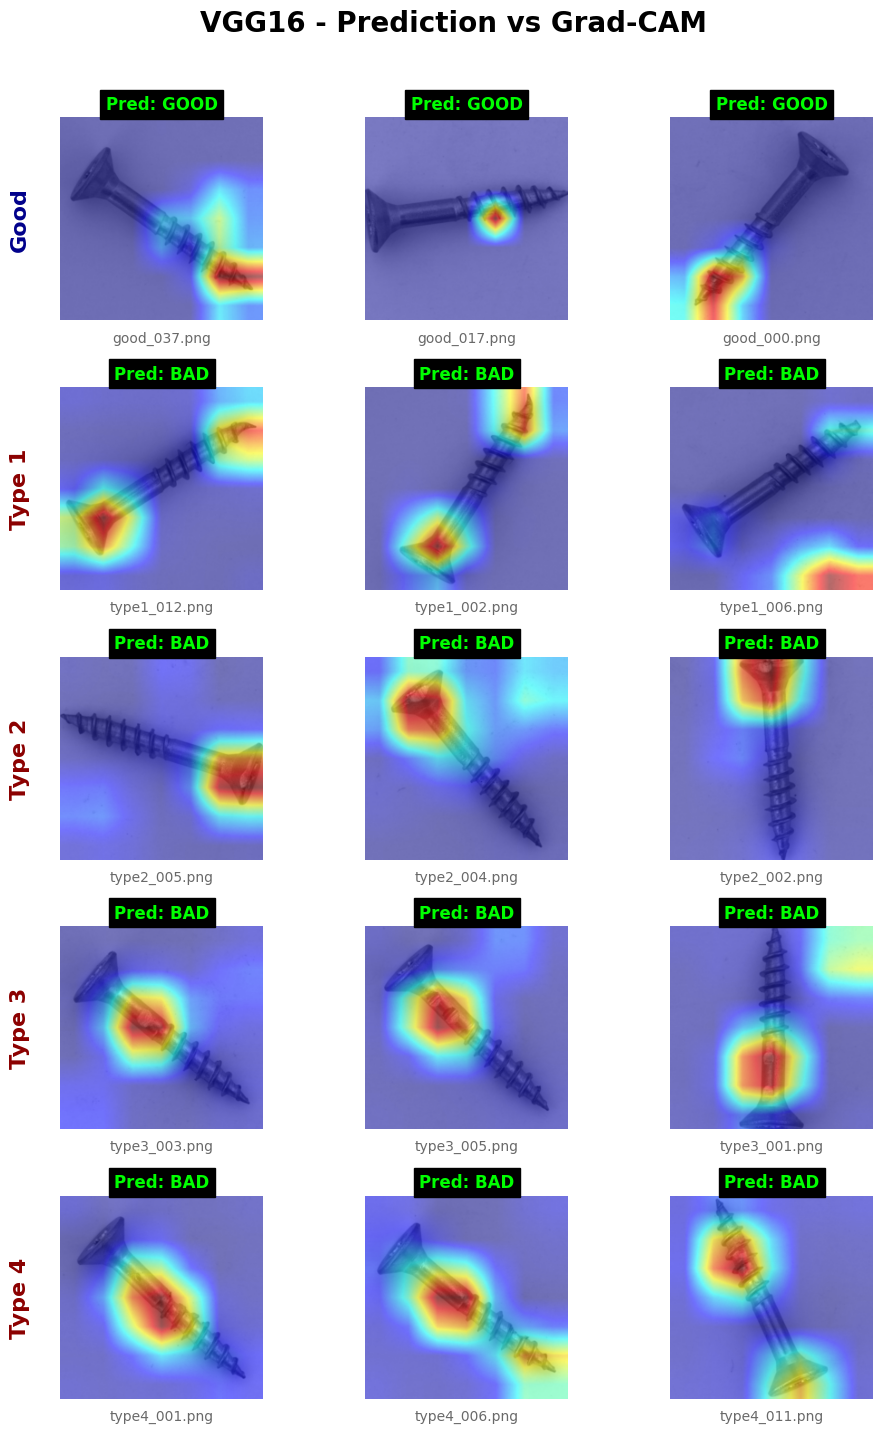

<Figure size 640x480 with 0 Axes>

In [21]:
model_name = 'vgg16'

best_model, val_recalls, val_f1s, val_f2_scores, test_y_true, test_y_pred, train_loss, val_loss = train_and_evaluate_model(
    model_name=model_name,
    dataloaders=dataloaders,
    dataset_sizes=dataset_sizes,
    class_names=class_names,
    device=device,
    run_dirs=run_dirs,
    num_epochs=40 
    )

best_f2 = max(val_f2_scores)
best_f2_scores.append(best_f2)
best_models_dict[model_name] = best_model

plot_confusion_matrix(test_y_true, test_y_pred, class_names, run_dirs['figures'], model_name=model_name)
plot_loss_history(train_loss, val_loss, run_dirs['figures'], model_name=model_name)
plot_weight_tradeoff(bad_weights, val_recalls, val_f1s, val_f2_scores, run_dirs['figures'], model_name=model_name)

test_transform = get_transforms()['test']
base_test_dir = f'{data_dir}/test'
show_gradcam_grid(best_model, test_transform, base_test_dir, device, run_dirs['figures'], model_name=model_name)


[ RESNET18 모델 평가 ]
측정 결과: 784.4 FPS (1장당 1.27 ms)

[ MOBILENET_V2 모델 평가 ]
측정 결과: 428.2 FPS (1장당 2.34 ms)

[ VGG16 모델 평가 ]
측정 결과: 508.7 FPS (1장당 1.97 ms)


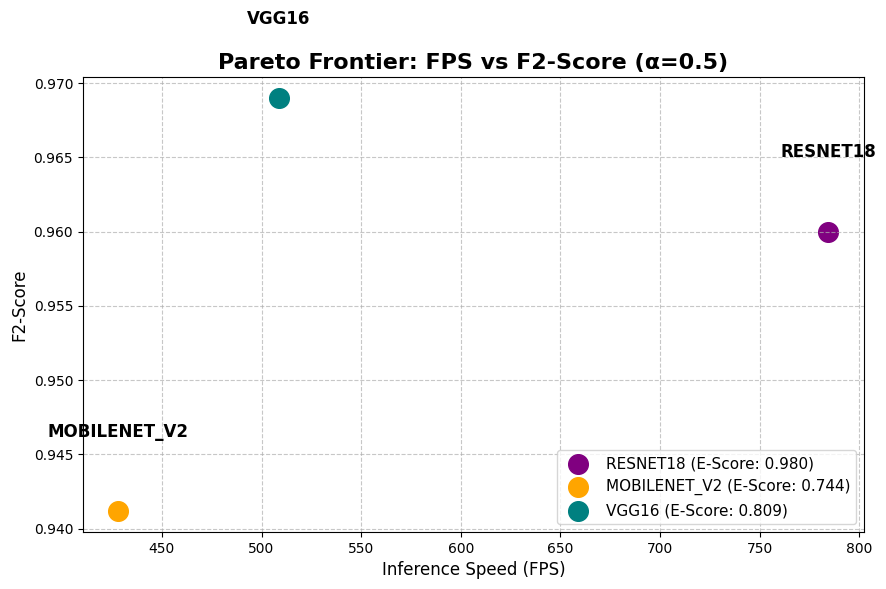

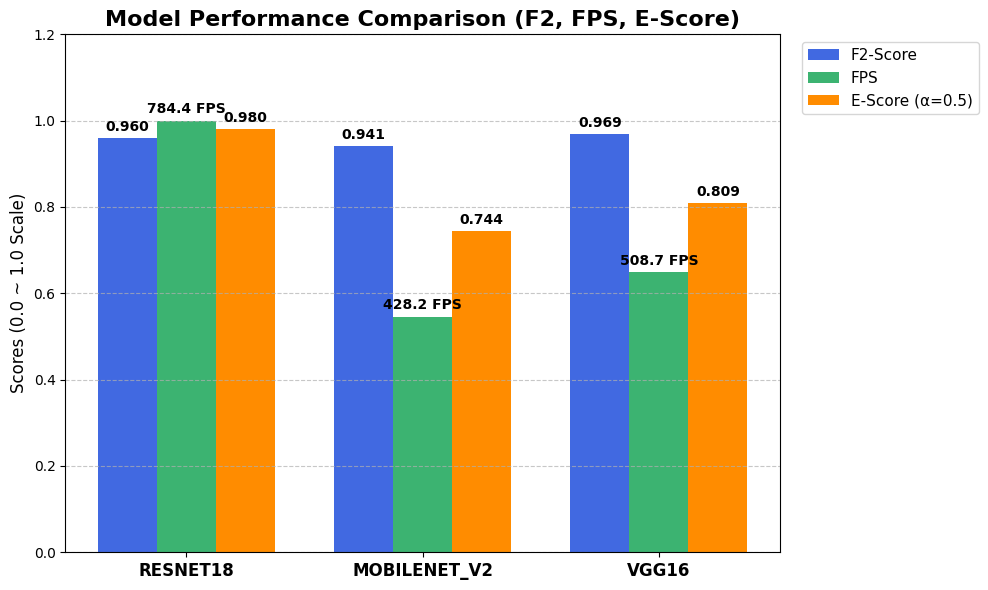

In [27]:
import importlib
import src.visualization
importlib.reload(src.visualization)
from src.visualization import plot_model_comparison_pareto, plot_model_comparison_bar

for model_name in ['resnet18', 'mobilenet_v2', 'vgg16']:
    print(f"\n[ {model_name.upper()} 모델 평가 ]")
    model = best_models_dict[model_name]
    fps, latency = measure_inference_speed(model, device, num_runs=100)
    fps_list.append(fps)

# GPU 기준 시각화
plot_model_comparison_pareto(
    model_names=['resnet18', 'mobilenet_v2', 'vgg16'], 
    f2_scores=best_f2_scores, 
    fps_list=fps_list, 
    alpha=0.5, 
    save_dir=run_dirs['figures'],
    device_label='GPU'
)
plot_model_comparison_bar(
    model_names=['resnet18', 'mobilenet_v2', 'vgg16'], 
    f2_scores=best_f2_scores, 
    fps_list=fps_list, 
    alpha=0.5,
    save_dir=run_dirs['figures'],
    device_label='GPU'
)

# CPU FPS 측정
device_cpu = torch.device('cpu')
fps_list_cpu = []
for model_name in ['resnet18', 'mobilenet_v2', 'vgg16']:
    model = best_models_dict[model_name]
    model_cpu = model.cpu()
    fps_cpu, _ = measure_inference_speed(model_cpu, device_cpu, num_runs=100)
    fps_list_cpu.append(fps_cpu)
    model.to(device)

# CPU 기준 시각화 (제목·파일명에 CPU 표시)
plot_model_comparison_pareto(
    model_names=['resnet18', 'mobilenet_v2', 'vgg16'], 
    f2_scores=best_f2_scores, 
    fps_list=fps_list_cpu, 
    alpha=0.5, 
    save_dir=run_dirs['figures'],
    device_label='CPU'
)
plot_model_comparison_bar(
    model_names=['resnet18', 'mobilenet_v2', 'vgg16'], 
    f2_scores=best_f2_scores, 
    fps_list=fps_list_cpu, 
    alpha=0.5,
    save_dir=run_dirs['figures'],
    device_label='CPU'
)

측정 결과: 106.0 FPS (1장당 9.43 ms)
resnet18: CPU 106.0 FPS
측정 결과: 105.3 FPS (1장당 9.50 ms)
mobilenet_v2: CPU 105.3 FPS
측정 결과: 26.3 FPS (1장당 37.96 ms)
vgg16: CPU 26.3 FPS


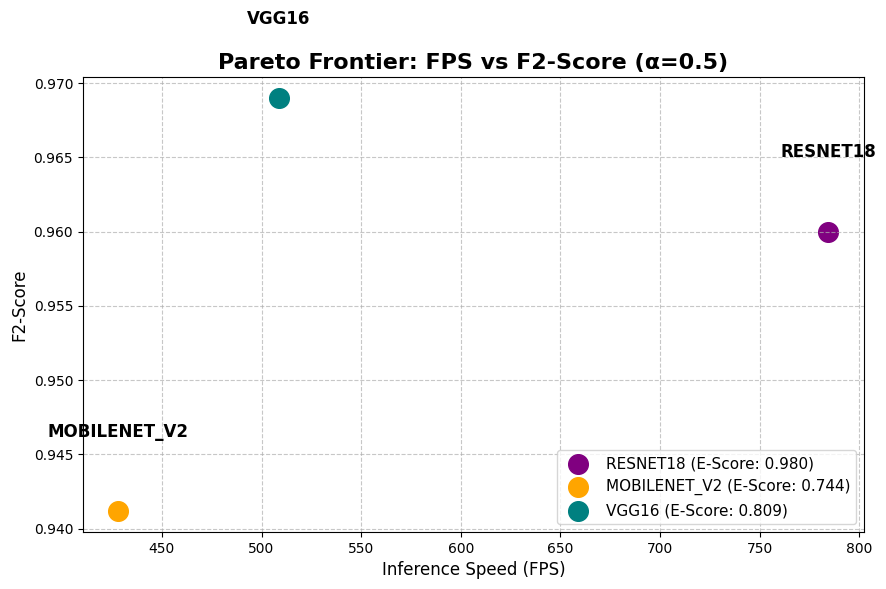

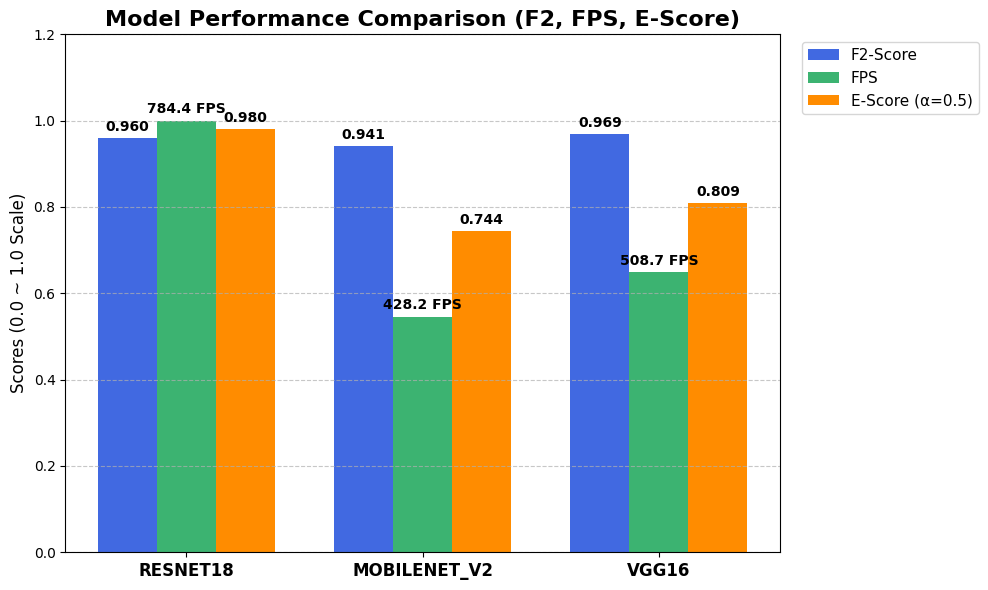

In [ ]:
# CPU에서 FPS 측정 (비교용)
device_cpu = torch.device('cpu')
for model_name in ['resnet18', 'mobilenet_v2', 'vgg16']:
    model = best_models_dict[model_name]
    model_cpu = model.cpu()  # 잠시 CPU로
    fps_cpu, latency_cpu = measure_inference_speed(model_cpu, device_cpu, num_runs=100)
    print(f"{model_name}: CPU {fps_cpu:.1f} FPS")
    model.to(device)  # 다시 GPU로 (다음 학습 등에 영향 없도록)

# plot_model_comparison_pareto(
#     model_names=['resnet18', 'mobilenet_v2', 'vgg16'], 
#     f2_scores=best_f2_scores, 
#     fps_list=fps_list, 
#     alpha=0.5, 
#     save_dir=run_dirs['figures']
# )

# plot_model_comparison_bar(
#     model_names=['resnet18', 'mobilenet_v2', 'vgg16'], 
#     f2_scores=best_f2_scores, 
#     fps_list=fps_list, 
#     alpha=0.5, # 0.5면 정확도와 속도를 5:5 비율로 평가하겠다는 뜻
#     save_dir=run_dirs['figures']
# )